<a href="https://colab.research.google.com/github/sitinurul2911-debug/autosummarizerAI/blob/main/Pemrograman_UTS_ADTT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on Google Colab


Saving data_review.csv to data_review.csv
Distribusi setelah drop netral:
label
0    1000
1    1000
Name: count, dtype: int64
Total data: 2000

Train: 1600 | Test: 400

Accuracy : 0.8075
Precision: 0.8075
Recall   : 0.8075
F1-Score : 0.8075

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.81      0.81      0.81       200
     Positif       0.81      0.81      0.81       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400


=== Info WordCloud ===
Panjang teks negatif: 102131 karakter, 17033 kata
Panjang teks positif: 46332 karakter, 7607 kata
 WordCloud Negatif berhasil dibuat
 WordCloud Positif berhasil dibuat

 Visualisasi disimpan ke: analisis_sentimen_shopee.png


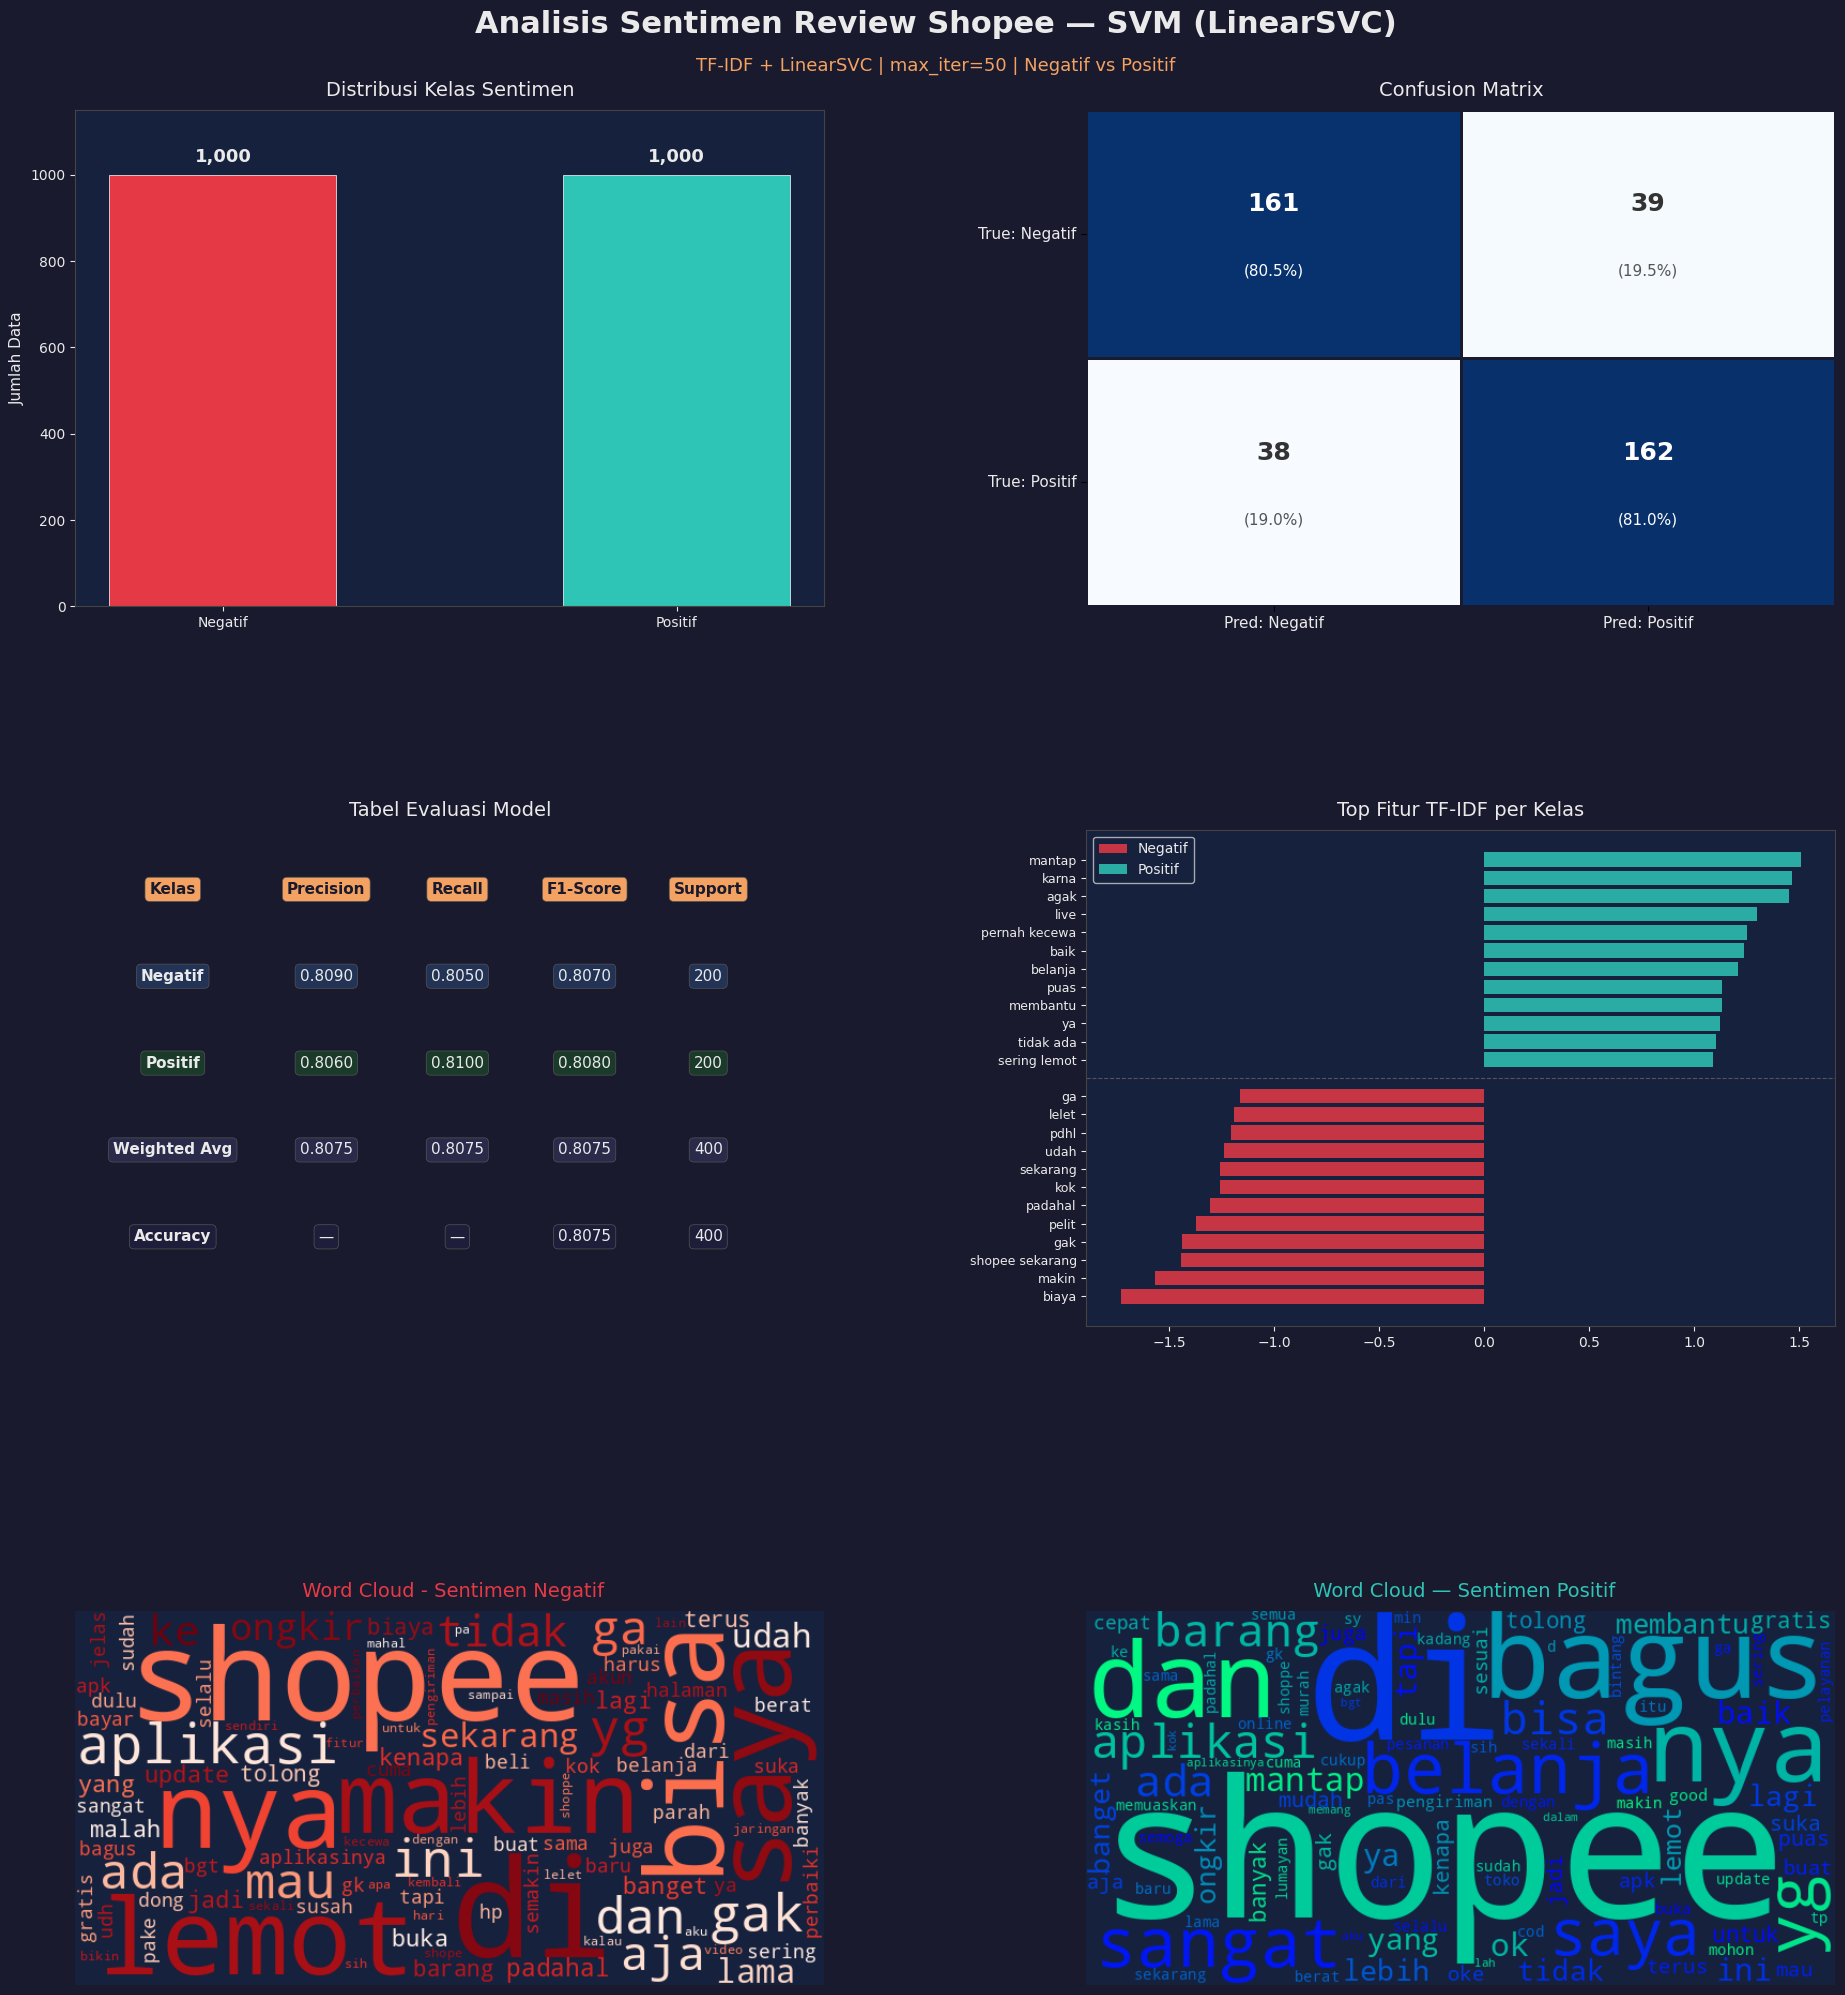

 Plot berhasil ditampilkan


In [ ]:
# Install dependencies
!pip install wordcloud -q

# Import library
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Setup visualisasi
try:
    from google.colab import files
    IN_COLAB = True
    %matplotlib inline
    print("Running on Google Colab")
except:
    IN_COLAB = False
    print("Running on local environment")

# Setup matplotlib backend
import sys
if 'ipykernel' in sys.modules:
    %matplotlib inline
elif not IN_COLAB:
    matplotlib.use('TkAgg')

# Upload file data_review sebagai dataset
if IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
else:
    file_name = 'data_review.csv'

# 1. Load & Preprocess
df = pd.read_csv(file_name)

# Drop neutral (score=3)
df = df[df['score'] != 3].copy()

# Label: 1-2 = Negatif (0), 4-5 = Positif (1)
df['label'] = df['score'].apply(lambda x: 0 if x <= 2 else 1)

print("Distribusi setelah drop netral:")
print(df['label'].value_counts())
print(f"Total data: {len(df)}")

# 2. Text Cleaning
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['content'].apply(clean_text)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# 4. TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# 5. SVM Training (dengan max_iter=50)
model = LinearSVC(max_iter=50, random_state=42, C=1.0)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

# 6. Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))

# 7. Cek data untuk WordCloud
neg_text = ' '.join(df[df['label'] == 0]['clean'].tolist())
pos_text = ' '.join(df[df['label'] == 1]['clean'].tolist())

print("\n=== Info WordCloud ===")
print(f"Panjang teks negatif: {len(neg_text)} karakter, {len(neg_text.split())} kata")
print(f"Panjang teks positif: {len(pos_text)} karakter, {len(pos_text.split())} kata")

if len(neg_text.strip()) == 0:
    print("PERINGATAN: Tidak ada teks negatif untuk wordcloud! Menggunakan dummy text.")
    neg_text = "tidak ada ulasan negatif"
if len(pos_text.strip()) == 0:
    print("PERINGATAN: Tidak ada teks positif untuk wordcloud! Menggunakan dummy text.")
    pos_text = "tidak ada ulasan positif"

# 8. Visualisasi
COLOR_NEG    = '#E63946'
COLOR_POS    = '#2EC4B6'
COLOR_BG     = '#1A1A2E'
COLOR_CARD   = '#16213E'
COLOR_TEXT   = '#EAEAEA'
COLOR_ACCENT = '#F4A261'

fig = plt.figure(figsize=(20, 22), facecolor=COLOR_BG)
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35,
               top=0.93, bottom=0.05, left=0.07, right=0.95)

fig.text(0.5, 0.965, 'Analisis Sentimen Review Shopee — SVM (LinearSVC)',
         ha='center', fontsize=22, fontweight='bold', color=COLOR_TEXT)
fig.text(0.5, 0.948, 'TF-IDF + LinearSVC | max_iter=50 | Negatif vs Positif',
         ha='center', fontsize=13, color=COLOR_ACCENT)

# Plot 1: Distribusi Kelas
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(COLOR_CARD)
labels_bar = ['Negatif', 'Positif']
counts = [sum(df['label'] == 0), sum(df['label'] == 1)]
bars = ax1.bar(labels_bar, counts, color=[COLOR_NEG, COLOR_POS], width=0.5,
               edgecolor='white', linewidth=0.5)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f'{cnt:,}', ha='center', va='bottom', fontsize=13,
             fontweight='bold', color=COLOR_TEXT)
ax1.set_title('Distribusi Kelas Sentimen', color=COLOR_TEXT, fontsize=14, pad=10)
ax1.set_ylabel('Jumlah Data', color=COLOR_TEXT, fontsize=11)
ax1.tick_params(colors=COLOR_TEXT)
ax1.spines[:].set_color('#444')
ax1.set_ylim(0, max(counts) * 1.15)

# Plot 2: Confusion Matrix
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLOR_CARD)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax2,
            linewidths=2, linecolor=COLOR_BG, cbar=False)
for i in range(2):
    for j in range(2):
        ax2.text(j + 0.5, i + 0.38, f'{cm[i, j]:,}',
                 ha='center', va='center', fontsize=18, fontweight='bold',
                 color='white' if cm[i, j] > cm.max() / 2 else '#333')
        ax2.text(j + 0.5, i + 0.65, f'({cm_norm[i, j]:.1%})',
                 ha='center', va='center', fontsize=11,
                 color='white' if cm[i, j] > cm.max() / 2 else '#555')
ax2.set_xticklabels(['Pred: Negatif', 'Pred: Positif'], color=COLOR_TEXT, fontsize=11)
ax2.set_yticklabels(['True: Negatif', 'True: Positif'], color=COLOR_TEXT, fontsize=11, rotation=0)
ax2.set_title('Confusion Matrix', color=COLOR_TEXT, fontsize=14, pad=10)

# Plot 3: Tabel Evaluasi
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(COLOR_CARD)
ax3.axis('off')
report = classification_report(y_test, y_pred, target_names=['Negatif', 'Positif'], output_dict=True)
table_data = [
    ['Kelas',        'Precision', 'Recall', 'F1-Score', 'Support'],
    ['Negatif',      f"{report['Negatif']['precision']:.4f}",
                     f"{report['Negatif']['recall']:.4f}",
                     f"{report['Negatif']['f1-score']:.4f}",
                     f"{int(report['Negatif']['support'])}"],
    ['Positif',      f"{report['Positif']['precision']:.4f}",
                     f"{report['Positif']['recall']:.4f}",
                     f"{report['Positif']['f1-score']:.4f}",
                     f"{int(report['Positif']['support'])}"],
    ['Weighted Avg', f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{len(y_test)}"],
    ['Accuracy',     '—',          '—',          f"{acc:.4f}", f"{len(y_test)}"],
]
col_widths  = [0.22, 0.19, 0.16, 0.18, 0.15]
row_colors  = [COLOR_ACCENT, '#223355', '#1a3a2a', '#2a2a4a', '#1e1e3a']
text_colors = [COLOR_BG, COLOR_TEXT, COLOR_TEXT, COLOR_TEXT, COLOR_TEXT]
y_pos = 0.88
for ri, (row, rc, tc) in enumerate(zip(table_data, row_colors, text_colors)):
    x_pos = 0.02
    for ci, (cell, cw) in enumerate(zip(row, col_widths)):
        fw = 'bold' if ri == 0 or ci == 0 else 'normal'
        ax3.text(x_pos + cw / 2, y_pos, cell, ha='center', va='center',
                 fontsize=11, color=tc if ri > 0 else COLOR_BG, fontweight=fw,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=rc,
                           edgecolor='#555', linewidth=0.5),
                 transform=ax3.transAxes)
        x_pos += cw
    y_pos -= 0.175
ax3.set_title('Tabel Evaluasi Model', color=COLOR_TEXT, fontsize=14, pad=10)

# Plot 4: Top Fitur TF-IDF
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(COLOR_CARD)
feature_names = np.array(tfidf.get_feature_names_out())
coef        = model.coef_[0]
top_n       = 12
top_pos_idx = np.argsort(coef)[-top_n:]
top_neg_idx = np.argsort(coef)[:top_n]
words_pos   = feature_names[top_pos_idx]
vals_pos    = coef[top_pos_idx]
words_neg   = feature_names[top_neg_idx]
vals_neg    = coef[top_neg_idx]
y_ticks     = range(top_n)
ax4.barh(y_ticks, vals_neg, color=COLOR_NEG, alpha=0.85, label='Negatif')
ax4.barh([t + top_n + 1 for t in y_ticks], vals_pos, color=COLOR_POS, alpha=0.85, label='Positif')
ax4.set_yticks(list(y_ticks) + [t + top_n + 1 for t in y_ticks])
ax4.set_yticklabels(list(words_neg) + list(words_pos), color=COLOR_TEXT, fontsize=9)
ax4.set_title('Top Fitur TF-IDF per Kelas', color=COLOR_TEXT, fontsize=14, pad=10)
ax4.tick_params(colors=COLOR_TEXT)
ax4.spines[:].set_color('#444')
ax4.axhline(top_n, color='#555', linewidth=0.8, linestyle='--')
ax4.legend(facecolor=COLOR_CARD, labelcolor=COLOR_TEXT, fontsize=10)

# Plot 5: Word Cloud Negatif
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor(COLOR_CARD)
try:
    wc_neg = WordCloud(width=700, height=350, background_color='#16213E',
                       colormap='Reds', max_words=100,
                       collocations=False).generate(neg_text)
    ax5.imshow(wc_neg, interpolation='bilinear')
    print(" WordCloud Negatif berhasil dibuat")
except Exception as e:
    print(f" Gagal membuat WordCloud Negatif: {e}")
    ax5.text(0.5, 0.5, 'Gagal membuat WordCloud\n(Teks terlalu pendek)',
             ha='center', va='center', color=COLOR_TEXT, fontsize=12,
             transform=ax5.transAxes)
ax5.axis('off')
ax5.set_title(' Word Cloud - Sentimen Negatif', color=COLOR_NEG, fontsize=14, pad=10)

# Plot 6: Word Cloud Positif
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor(COLOR_CARD)
try:
    wc_pos = WordCloud(width=700, height=350, background_color='#16213E',
                       colormap='winter', max_words=100,
                       collocations=False).generate(pos_text)
    ax6.imshow(wc_pos, interpolation='bilinear')
    print(" WordCloud Positif berhasil dibuat")
except Exception as e:
    print(f" Gagal membuat WordCloud Positif: {e}")
    ax6.text(0.5, 0.5, 'Gagal membuat WordCloud\n(Teks terlalu pendek)',
             ha='center', va='center', color=COLOR_TEXT, fontsize=12,
             transform=ax6.transAxes)
ax6.axis('off')
ax6.set_title(' Word Cloud — Sentimen Positif', color=COLOR_POS, fontsize=14, pad=10)

# 9. Menampilkan dan Menyimpan Visualisasi
plt.tight_layout()

# Simpan ke file
output_file = 'analisis_sentimen_shopee.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight', facecolor=COLOR_BG)
print(f"\n Visualisasi disimpan ke: {output_file}")

# Tampilkan plot
try:
    plt.show(block=True)
    print(" Plot berhasil ditampilkan")
except Exception as e:
    print(f" Plot tidak bisa ditampilkan: {e}")
    print(f"  Silakan buka file '{output_file}' untuk melihat hasil visualisasi")